In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import least_squares

from diffpy.mpdf import *

import maginteractions

from diffpy.structure import loadStructure

%matplotlib notebook

In [2]:
# build magstruc with primitive unit cell

triclinic = False

structure_file = 'NaMnO2Data/fitStruc_triShortRange_005K.cif'

NaMnO2 = loadStructure(structure_file)

if triclinic:
    a = NaMnO2.lattice.a
    b = NaMnO2.lattice.b
    c = NaMnO2.lattice.c
    alpha = NaMnO2.lattice.alpha
    beta = NaMnO2.lattice.beta
    gamma = NaMnO2.lattice.gamma
else:
    a = b = 3.17167
    c = 5.79900
    alpha = beta = 110.4993
    gamma = 53.5987
    NaMnO2.lattice.a = a
    NaMnO2.lattice.b = b
    NaMnO2.lattice.c = c
    NaMnO2.lattice.alpha = alpha
    NaMnO2.lattice.beta = beta
    NaMnO2.lattice.gamma = gamma
    
print(NaMnO2)

lattice=Lattice(a=3.17167, b=3.17167, c=5.799, alpha=110.499, beta=110.499, gamma=53.5987)
Na   0.500000 0.500000 0.500000 1.0000
Mn   0.000000 0.000000 0.000000 1.0000
O    0.709026 0.704427 0.204309 1.0000
O    0.290974 0.295573 0.795691 1.0000


In [3]:
mspec = MagSpecies()
mspec.struc = NaMnO2
mspec.label = 'Mn3+'
mspec.strucIdxs = [0]
mspec.basisvecs = np.array([[1.0, 1.0, 0]])
mspec.origin = np.array([0, 0, 0])
mspec.ffparamkey = 'Mn3'

magstruc = MagStructure()
magstruc.loadSpecies(mspec)
magstruc.makeAll()

In [4]:
# populate spins with mcif

mcif = 'NaMnO2Data/1.409_NaMnO2.mcif'
mstruc0 = create_from_mcif(mcif, ffparamkey='Mn2')
mstruc0.makeAll()

# rotate mcif spins/atoms to match current magstruc orientation
theta = -1.0571653032274788
rotation_matrix = np.array([[np.cos(theta), -np.sin(theta), 0],
                           [np.sin(theta), np.cos(theta), 0],
                           [0, 0, 1]])

magstruc.spins = mstruc0.spins @ rotation_matrix
magstruc.atoms = mstruc0.atoms @ rotation_matrix
magstruc.calcIdxs = mstruc0.calcIdxs

MagStructure creation from mcif file successful.


<IPython.core.display.Javascript object>


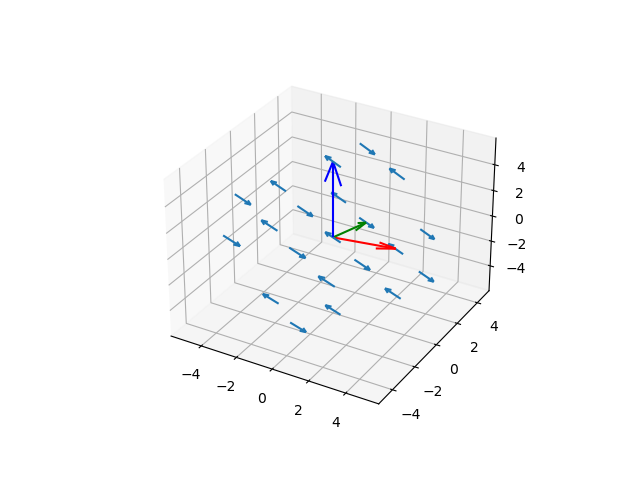

In [5]:
distances = np.apply_along_axis(np.linalg.norm, 1, magstruc.atoms)
viewmask = distances < 6
magstruc.visualize(magstruc.atoms[viewmask], magstruc.spins[viewmask], showcrystalaxes=True)

In [6]:
### import data

high_idx = 6 # index where paramagnet data starts

[data_temps, xi_data, xi_err] = np.loadtxt('NaMnO2Data/mPDFresults_NaMnO2_xi-vs-T.txt',
                                           delimiter = ' ', skiprows = 2).T
[data_temps_high, xi_high_data, xi_high_err] = np.loadtxt('NaMnO2Data/mPDFresults_NaMnO2_xi-vs-T.txt',
                                                          delimiter = ' ', skiprows = 2)[high_idx:].T

[_, lmop_data, lmop_err] = np.loadtxt('NaMnO2Data/mPDFresults_NaMnO2_m-vs-T.txt',
                                      delimiter = ' ', skiprows = 2).T
[_, lmop_high_data, lmop_high_err] = np.loadtxt('NaMnO2Data/mPDFresults_NaMnO2_m-vs-T.txt',
                                                delimiter = ' ', skiprows = 2)[high_idx:].T

lmop_data = 2 * np.sqrt(lmop_data)
lmop_err = 0.5 * lmop_data * lmop_err / (lmop_data / 2) ** 2

lmop_high_data = 2 * np.sqrt(lmop_high_data)
lmop_high_err = 0.5 * lmop_high_data * lmop_high_err / (lmop_high_data / 2) ** 2

In [7]:
xi_data[6]

27.320646246075345

# Previously published values

In [8]:
temps = data_temps # np.linspace(0.1,600.0,20)

In [9]:
j_ij_zorko = -65.0 * np.array([1, 0.44]) # Zorko 2008
j_ij_dally = np.array([-6.16, -0.77])/8.617333262e-2 # Dally 2018

j_ij_wadhwa_1 = np.array([-11.3,-3.26])/8.617333262e-2 # Wadhwa 2025
j_ij_wadhwa_2 = np.array([-3.87,-0.82])/8.617333262e-2
j_ij_wadhwa_3 = np.array([-6.37,-0.65])/8.617333262e-2
j_ij_wadhwa_4 = np.array([-6.1,-0.55])/8.617333262e-2

j_ijs = [j_ij_zorko, j_ij_dally, j_ij_wadhwa_1, j_ij_wadhwa_2, j_ij_wadhwa_3, j_ij_wadhwa_4]
j_ij_names = ["Zorko et al.", "Dally et al.", "Wadhwa 1", "Wadhwa 2", "Wadhwa 3", "Wadhwa 4"]

In [10]:
r_max = 5.0
spin_squared = 4

j_ij_test = j_ij_zorko
magint_test = maginteractions.MagInteractions(magstruc = magstruc, temperatures = temps, j_ij = j_ij_test,
                                              spin_squared = spin_squared, r_max = r_max)
magint_test.make_interaction_matrix()
magint_test.calculate_orf_reciprocal_space(n_bz_vecs = 4)

orfs_reciprocal_space = magint_test.orfs.copy()

/home/edison/Documents/Projects/MagInteractions/maginteractions.py:225: ComplexWarning: Casting complex values to real discards the imaginary part
  u_q[k] = eig_vecs.astype('float64')


<IPython.core.display.Javascript object>


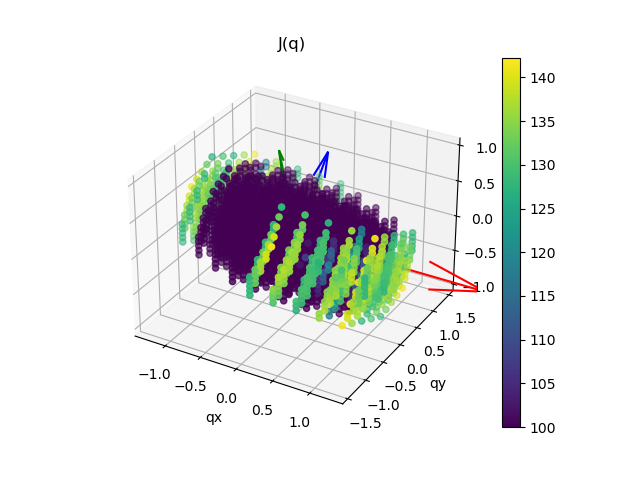

In [11]:
# visualize J(q)

import matplotlib.colors as mcolors

qxs, qys, qzs = magint_test.q_vecs.T

vmin = 100
vmax = 142.25

qa = 2 * np.pi / a
qb = 2 * np.pi / b
qc = 2 * np.pi / c


fig, ax = plt.subplots(subplot_kw = {"projection": "3d"})
norm = mcolors.Normalize(vmin = vmin, vmax = vmax)
j_q_plot = ax.scatter(qxs, qys, qzs, c = magint_test.j_q[:,-1], norm = norm)
fig.colorbar(j_q_plot)

rl_a, rl_b, rl_c = magint_test.recip_lats

ax.quiver(0, 0, 0, rl_a[0], rl_a[1], rl_a[2], pivot='tail', color='r')
ax.quiver(0, 0, 0, rl_b[0], rl_b[1], rl_b[2], pivot='tail', color='g')
ax.quiver(0, 0, 0, rl_c[0], rl_c[1], rl_c[2], pivot='tail', color='b')

ax.set_title('J(q)')
ax.set_xlabel('qx')
ax.set_ylabel('qy')
ax.set_zlabel('qz')
plt.show()

In [12]:
print('From BZ recreation')
print(f'Jq = {np.max(magint_test.j_q[:,-1])}')
idx = np.argmax(magint_test.j_q[:,-1], axis = None)
qmax = magint_test.q_vecs[idx]
print(f'q = {qmax}')
print(f'q = {qmax @ np.linalg.inv(magint_test.recip_lats)} (rlu)')
print(f'q = {qmax * np.array([1 / qa, 1 / qb, 1 / qc])} (units of 2pi/a)')

From BZ recreation
Jq = 141.37822901033488
q = [-1.14196154  0.62711063  0.        ]
q = [-0.29651174  0.29651174  0.        ] (rlu)
q = [-0.57644729  0.31655727  0.        ] (units of 2pi/a)


<IPython.core.display.Javascript object>


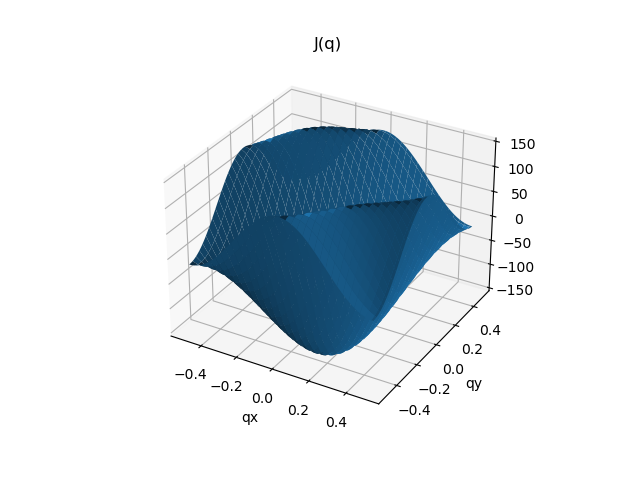

In [13]:
# visualize J(q) at qz=0

qa = 2 * np.pi / a
qb = 2 * np.pi / b
qc = 2 * np.pi / c

qx = np.linspace(-0.5, 0.5, 101)
qy = np.linspace(-0.5, 0.5, 101)
qx, qy = np.meshgrid(qx, qy)
qz = 0.0


j_qs = np.zeros((magint_test.N, 1) + qx.shape)
u_qs = np.zeros((magint_test.N, magint_test.N, 1) + qx.shape)
for i in range(qx.shape[0]):
    for j in range(qx.shape[1]):
        qv = np.array([qx[i,j], qy[i,j], qz]) @ magint_test.recip_lats
        j_qs[:,:,i,j], u_qs[:,:,:,i,j] = magint_test.calc_j_q(qv, return_eig_vecs = True)
        
j_qs = j_qs.reshape((magint_test.N,) + qx.shape)
u_qs = u_qs.reshape((magint_test.N,magint_test.N,) + qx.shape)

tidx = 5

for k in range(magint_test.N):
    fig, ax = plt.subplots(subplot_kw = {"projection": "3d"})
    ax.plot_surface(qx, qy, j_qs[k])
    ax.set_zlim(-150, 150)
    ax.set_title('J(q)')
    ax.set_xlabel('qx')
    ax.set_ylabel('qy')
    plt.show()

In [14]:
print(f'From qz = {qz} slice')
print(f'Jq = {np.max(j_qs)}')
idx = np.unravel_index(np.argmax(j_qs, axis=None), j_qs.shape)
qmax = np.array([qx[idx[1:]], qy[idx[1:]], qz]) @ magint_test.recip_lats
print(f'q = {qmax}')
print(f'q = {qmax @ np.linalg.inv(magint_test.recip_lats)} (rlu)')
print(f'q = {qmax * np.array([1 / qa, 1 / qb, 1 / qc])} (units of 2pi/a)')

From qz = 0.0 slice
Jq = 142.5707895607157
q = [ 1.09181896 -0.61333855  0.        ]
q = [ 0.28 -0.29  0.  ] (rlu)
q = [ 0.55113597 -0.3096053   0.        ] (units of 2pi/a)


<IPython.core.display.Javascript object>


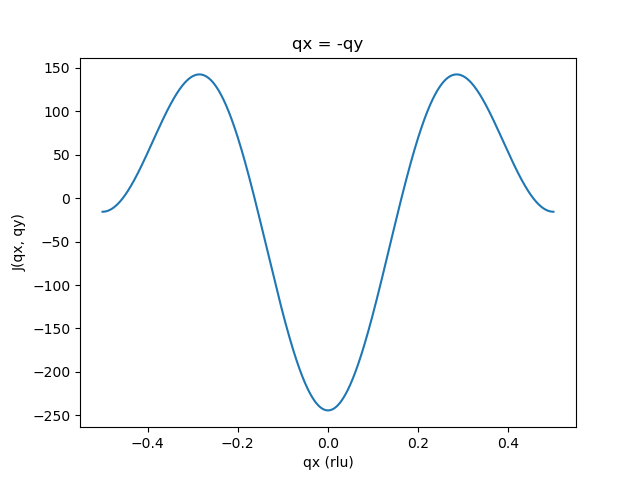

In [15]:
qxys = np.linspace(-0.5, 0.5, 1001)
jqxy = np.array([magint_test.calc_j_q(qxy * np.array([1, -1, 0]) @ magint_test.recip_lats)[0] for qxy in qxys])

fig, ax = plt.subplots()
ax.plot(qxys, jqxy)
ax.set_xlabel('qx (rlu)')
ax.set_ylabel('J(qx, qy)')
ax.set_title('qx = -qy')
plt.show()

<IPython.core.display.Javascript object>


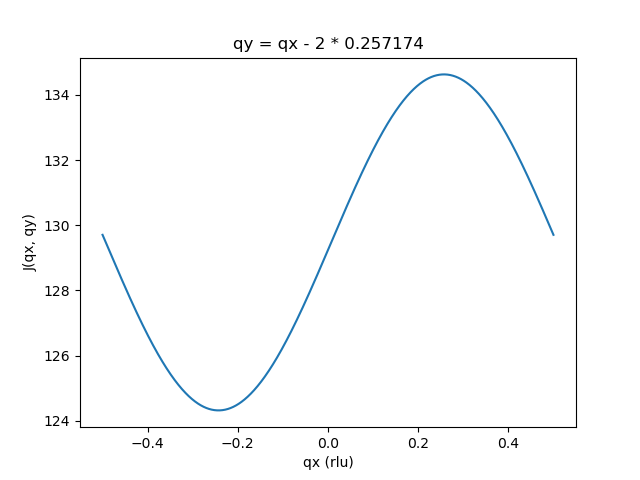

In [16]:
qxys = np.linspace(-0.5, 0.5, 1001)
jqxy = np.array([magint_test.calc_j_q(np.array([qxy, qxy - 2 * 0.257174, 0]) @ magint_test.recip_lats)[0]
                 for qxy in qxys])

fig, ax = plt.subplots()
ax.plot(qxys,jqxy)
ax.set_xlabel('qx (rlu)')
ax.set_ylabel('J(qx, qy)')
ax.set_title('qy = qx - 2 * 0.257174')
plt.show()

Maxima near:
(1/4, -1/4, 0)
(-1/4, 1/4, 0)

0.2853028694288763 -0.2853028694288762


/home/edison/anaconda3/envs/diffpy/lib/python3.7/site-packages/diffpy/mpdf/magstructure.py:987: RuntimeWarning: invalid value encountered in true_divide
  distanceVecsN = distanceVecs/np.apply_along_axis(np.linalg.norm,1,distanceVecs)[:,np.newaxis]


29.35935497249447


<IPython.core.display.Javascript object>


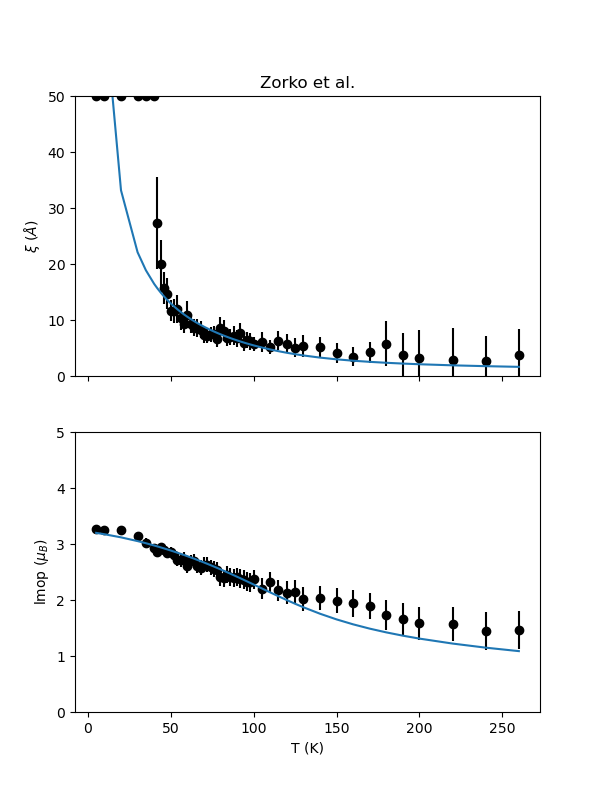

0.2599536713846443 -0.25995367138464437
33.428357056302445


<IPython.core.display.Javascript object>


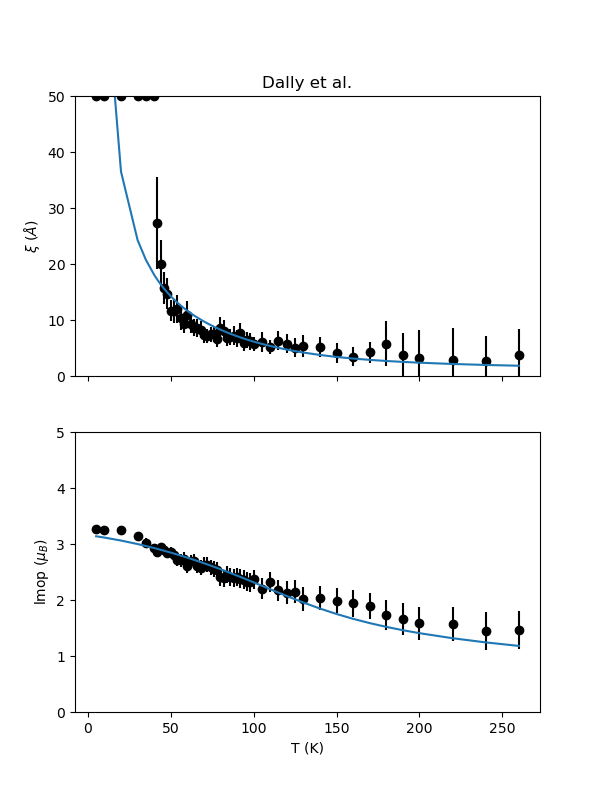

0.2730381185273264 -0.2730381185273264
326.5707576963632


<IPython.core.display.Javascript object>


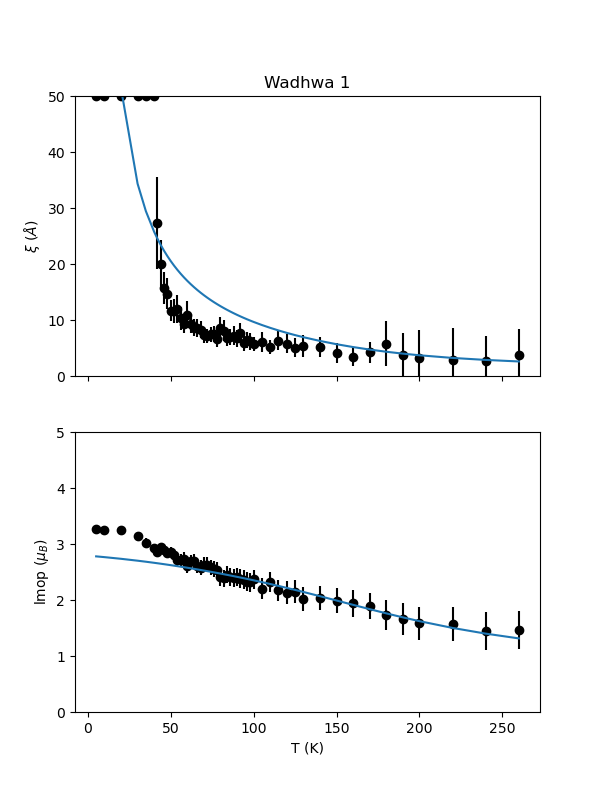

0.26689307866212775 -0.26689307866212775
73.7606764509171


<IPython.core.display.Javascript object>


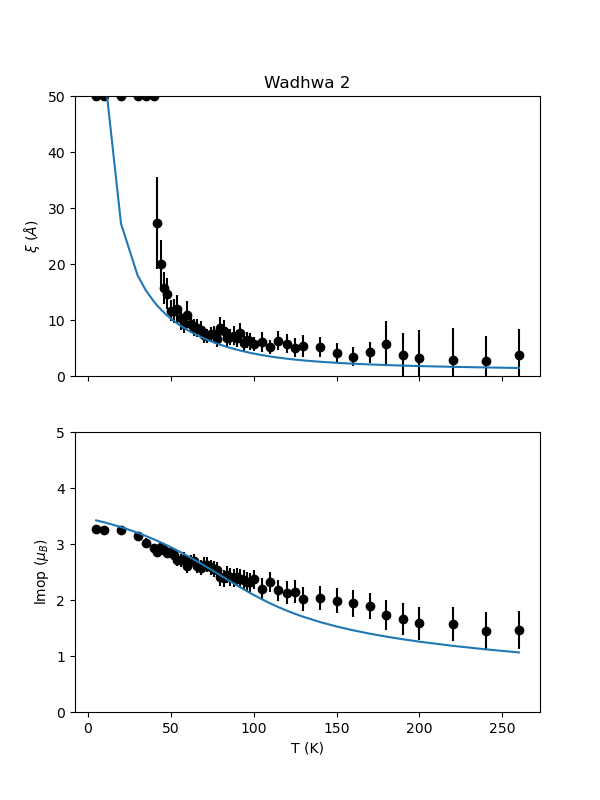

0.25812367719368956 -0.25812367719368956
38.16909430856951


<IPython.core.display.Javascript object>


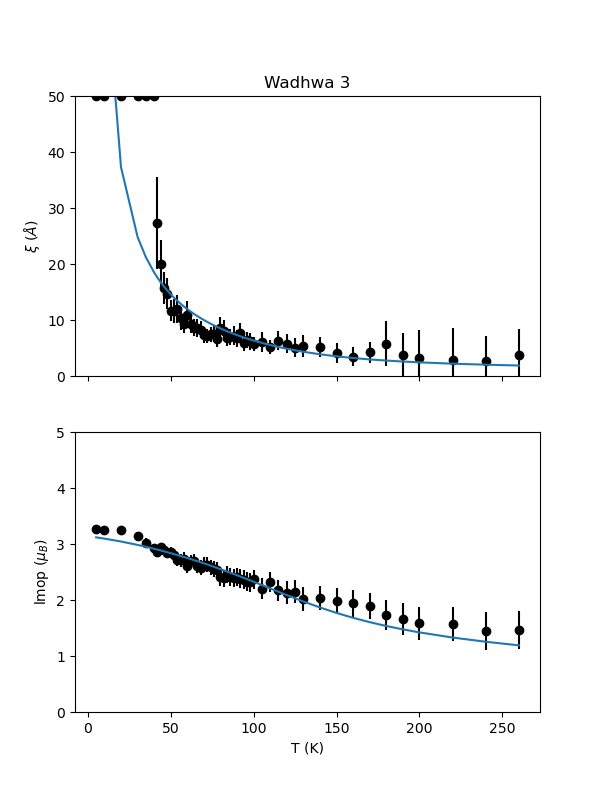

0.25717745055007046 -0.2571774505500705
32.33027005977242


<IPython.core.display.Javascript object>


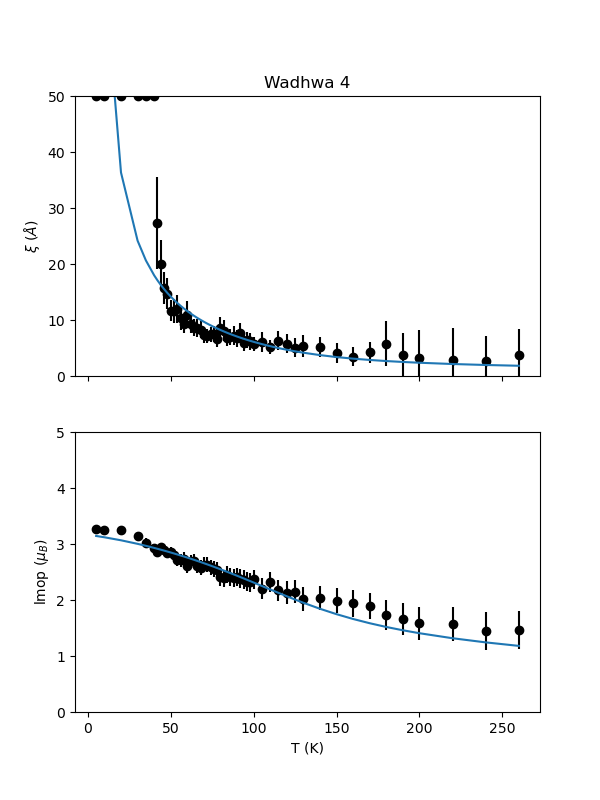

In [17]:
r_max = 5.0
n_ord_vec = 2
calc_orf = True
dim = 1

# spin_squared_list = [3.029502621455444, 2.9723206656016234, 2.1237506517324305,
#            3.664164472568528, 2.9304865092693193, 2.9951502492407354]

xis_list = np.zeros((len(j_ijs), len(temps)))
lmop_list = np.zeros((len(j_ijs), len(temps)))
spin_squared_list = np.zeros((len(j_ijs)))

for i, j_ij in enumerate(j_ijs):
    
    j1, j2 = j_ij

    j_ratio = j2 / j1
    kvecx = 0.5 + (np.arcsin(j_ratio * np.sqrt(1 - 0.25 * j_ratio**2)) - np.arccos(-0.5 * j_ratio)) / (2 * np.pi)
    kvecy = -np.arccos(-0.5 * j_ratio) / (2 * np.pi)
    
    print(kvecx, kvecy)
    
    def calc_corr_parameters(spin_sq):
        
        magint = maginteractions.MagInteractions(magstruc=magstruc, temperatures=temps, j_ij=j_ij,
                                                 spin_squared=spin_sq, r_max=r_max, spin_dim=3)
        magint.make_interaction_matrix()
        magint.filter_spin_positions()
        ord_vec = np.array([kvecx, kvecy, 0]) @ magint.recip_lats

        magint.calculate_correlation_parameters(ord_vec=ord_vec, n_ord_vec=n_ord_vec, calc_orf=True,
                                                dim=dim, sum_rule_orf=False, n_bz_vecs=4, isotropic=False)
        xis = np.sort(np.linalg.eigvals(magint.damping_matrices), axis=1)[:,0]**(-1/2)
        
        return xis, magint.lmops
        
    
    def residuals(theta):
        spin_sq = theta[0]
        
        xis, lmops = calc_corr_parameters(theta[0])
        xis = xis[high_idx:]
        lmops = lmops
        
        res = np.concatenate([xis,lmops]) - np.concatenate([xi_high_data, lmop_data])
        weights = 1/np.concatenate([xi_high_err,lmop_err])
        res *= weights
        res = np.nan_to_num(res,nan=1e4)
        return res
    
    bounds = (0, 6)
    theta = [4]
    result = least_squares(residuals, theta, method='dogbox', bounds=bounds)
    
    print(result.cost)
    
    xis, lmops = calc_corr_parameters(result.x[0])
    xis_list[i] = xis
    lmop_list[i] = lmops
    spin_squared_list[i] = result.x[0]
    
    fig, (ax1, ax2) = plt.subplots(2, 1, sharex = True, figsize = (6, 8))

    ax1.scatter(data_temps, xi_data, c = 'black')
    ax1.errorbar(data_temps, xi_data, yerr = xi_err, fmt = 'none', c = 'black')
    ax1.plot(temps, xis)
    ax1.set_ylim(0, 50)
    ax1.set_ylabel(r'$\xi$ ($\AA$)')
    ax1.set_title(j_ij_names[i])

    ax2.scatter(data_temps, lmop_data, c = 'black')
    ax2.errorbar(data_temps, lmop_data, yerr = lmop_err,fmt = 'none', c = 'black')
    ax2.plot(temps, lmops)

    ax2.set_ylim(0, 5)
    ax2.set_xlabel('T (K)')
    ax2.set_ylabel(r'lmop ($\mu_B$)')

    plt.show()

In [18]:
print(spin_squared_list)

[2.3580628  2.47320519 1.86735153 2.91151748 2.44817682 2.49147756]


In [19]:
magint = maginteractions.MagInteractions(magstruc=magstruc, temperatures=temps, j_ij=j_ij_zorko,
                                                 spin_squared=spin_squared_list[0], r_max=r_max, spin_dim=3)
magint.make_interaction_matrix()
magint.filter_spin_positions()
magint.calculate_orf_reciprocal_space(n_bz_vecs = 4)
recip_orfs = magint.orfs.copy()

ord_vec = np.array([kvecx, kvecy, 0]) @ magint.recip_lats

magint.calculate_correlation_parameters(ord_vec=ord_vec, n_ord_vec=n_ord_vec, calc_orf=True,
                                        dim=dim, sum_rule_orf=False, n_bz_vecs=4, isotropic=False)

<IPython.core.display.Javascript object>


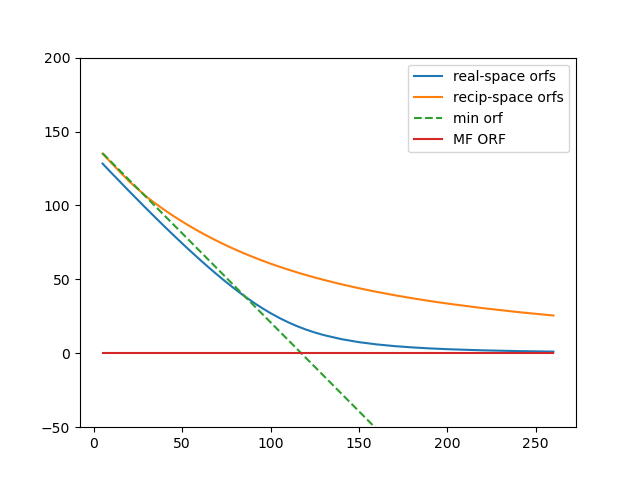

In [20]:
fig, ax = plt.subplots()
ax.plot(temps, magint.orfs, label = 'real-space orfs')
ax.plot(temps, recip_orfs, label = 'recip-space orfs')
# ax.plot(temps, experimental_orfs, label = 'experimental orfs')
ax.plot(temps, np.max(magint.j_q) - 3 * temps / spin_squared_list[-1], '--', label = 'min orf')
ax.plot(temps, np.zeros_like(temps), label = 'MF ORF')
ax.set_ylim(-50, 200)
ax.legend()
plt.show()

<IPython.core.display.Javascript object>


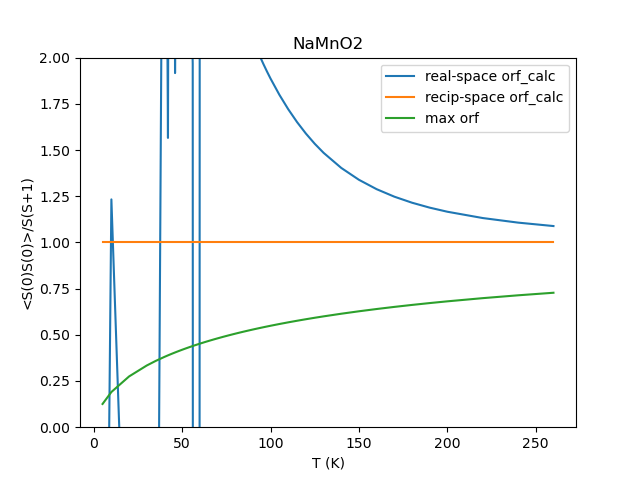

In [21]:
chi_0 = magint.calc_chi_0()
orf_sum_real = np.array([np.sum((1 - chi_0[i] * (magint.j_q - magint.orfs[i]))**(-1))
                         for i in range(len(temps))])
orf_sum_recip = np.array([np.sum((1 - chi_0[i] * (magint.j_q - recip_orfs[i]))**(-1))
                          for i in range(len(temps))])
orf_sum_max = np.array([np.sum((1 - chi_0[i] * (magint.j_q - np.max(magint.j_q)))**(-1))
                        for i in range(len(temps))])

fig, ax = plt.subplots()
ax.plot(temps, orf_sum_real / (magint.N * len(magint.q_vecs)), label='real-space orf_calc')
ax.plot(temps, orf_sum_recip / (magint.N * len(magint.q_vecs)), label='recip-space orf_calc')
ax.plot(temps, orf_sum_max / (magint.N * len(magint.q_vecs)), label='max orf')
ax.set_xlabel('T (K)')
ax.set_ylabel('<S(0)S(0)>/S(S+1)')
ax.set_title('NaMnO2')
ax.legend()
ax.set_ylim(0, 2)
plt.show()

/home/edison/anaconda3/envs/diffpy/lib/python3.7/site-packages/diffpy/mpdf/magstructure.py:987: RuntimeWarning: invalid value encountered in true_divide
  distanceVecsN = distanceVecs/np.apply_along_axis(np.linalg.norm,1,distanceVecs)[:,np.newaxis]


<IPython.core.display.Javascript object>


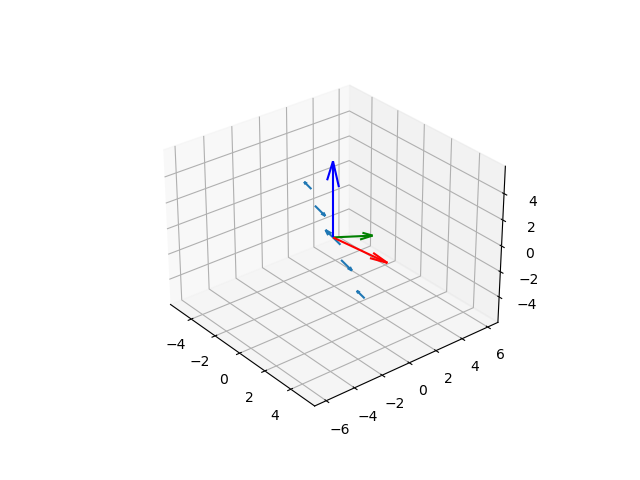

In [64]:
mPDF_tidx = 10

mstruc = magstruc.copy()
mstruc.dampingMat = magint.damping_matrices[mPDF_tidx]
mstruc.spins = mstruc.generateScaledSpins()

distances = np.apply_along_axis(np.linalg.norm, 1, mstruc.atoms)
viewmask = distances < 7
mstruc.visualize(mstruc.atoms[viewmask], mstruc.spins[viewmask], showcrystalaxes=True)

# Fit

In [23]:
def residuals(theta):
    
    j1, j2, spin_sq = theta
    j_ij = [j1, j2]
    
    j_ratio = j2 / j1
    kvecx = 0.5 + (np.arcsin(j_ratio * np.sqrt(1 - 0.25 * j_ratio**2)) - np.arccos(-0.5 * j_ratio)) / (2 * np.pi)
    kvecy = -np.arccos(-0.5 * j_ratio) / (2 * np.pi)
    
    magint = maginteractions.MagInteractions(magstruc=magstruc, temperatures=temps, j_ij=j_ij,
                                                 spin_squared=spin_sq, r_max=r_max, spin_dim=3)
    magint.make_interaction_matrix()
    magint.filter_spin_positions()

    ord_vec = np.array([kvecx, kvecy, 0]) @ magint.recip_lats

    magint.calculate_correlation_parameters(ord_vec=ord_vec, n_ord_vec=n_ord_vec, calc_orf=True,
                                            dim=dim, sum_rule_orf=False, n_bz_vecs=4, isotropic=False)
    xis = np.sort(np.linalg.eigvals(magint.damping_matrices), axis=1)[:,0]**(-1/2)
    lmops = magint.lmops
    
    xis = xis[high_idx:]
    lmops = lmops
    
    res = np.concatenate([xis,lmops]) - np.concatenate([xi_high_data, lmop_data])
    weights = 1/np.concatenate([xi_high_err,lmop_err])
    res *= weights
    res = np.nan_to_num(res,nan=1e4)
    return res

bounds = ([-np.inf, -np.inf, 0],[0, 0, np.inf])
# theta = [j_ij_zorko[0], j_ij_zorko[1], spin_squared_list[0]]
theta = [-65.0, -25.0, 2.5]

result = least_squares(residuals, theta, method='dogbox', bounds=bounds)

In [24]:
j1, j2, spin_sq = result.x
j_ij = [j1, j2]

j_ratio = j2 / j1
kvecx = 0.5 + (np.arcsin(j_ratio * np.sqrt(1 - 0.25 * j_ratio**2)) - np.arccos(-0.5 * j_ratio)) / (2 * np.pi)
kvecy = -np.arccos(-0.5 * j_ratio) / (2 * np.pi)

magint_fit = maginteractions.MagInteractions(magstruc=magstruc, temperatures=temps, j_ij=j_ij,
                                             spin_squared=spin_sq, r_max=r_max, spin_dim=3)
magint_fit.make_interaction_matrix()
magint_fit.filter_spin_positions()

ord_vec = np.array([kvecx, kvecy, 0]) @ magint_fit.recip_lats

magint_fit.calculate_correlation_parameters(ord_vec=ord_vec, n_ord_vec=n_ord_vec, calc_orf=True,
                                        dim=dim, sum_rule_orf=False, n_bz_vecs=4, isotropic=False)
xis_fit = np.sort(np.linalg.eigvals(magint_fit.damping_matrices), axis=1)[:,0]**(-1/2)
lmops_fit = magint_fit.lmops

In [25]:
print(result.jac.T @ result.jac)
print(np.diag(result.jac.T @ result.jac)**(-1/2))
print(np.diag(np.linalg.inv(result.jac.T @ result.jac))**(1/2))

[[  14.53764222   57.74191427 -183.41494315]
 [  57.74191427  234.59437292 -742.91750413]
 [-183.41494315 -742.91750413 2528.49276207]]
[0.26227265 0.06528918 0.01988699]
[1.75800033 0.48331233 0.07562409]


In [26]:
for i, j in enumerate(result.x):
    if i != 2:
        print(f'J{i+1}={j}')

print(f'S^2={result.x[2]}')

print(f'Cost = {result.cost}')

J1=-65.4246440904384
J2=-23.916166337977558
S^2=2.417672515723801
Cost = 28.19728844755904


In [69]:
rdat, mpdf_obs, mpdf_calc, _ = np.loadtxt('NaMnO2Data/mPDFfitSub280_50.0K.txt', skiprows=2, delimiter=' ').T

mpdf_tidx = 10

paraScale = 0.01

mstruc = magstruc.copy()

mstruc.dampingMat = magint_fit.damping_matrices[mpdf_tidx]
mc = MPDFcalculator(mstruc, qmax=35.0, qdamp=0.03, rmin=1.5)
mc.paraScale = paraScale
mc.ordScale = magutils.calculate_ordered_scale(mstruc,lmops_fit[mpdf_tidx])
rcalc, dcalc = mc.calc(correlationMethod='full', normalized=False, both=False)

<IPython.core.display.Javascript object>


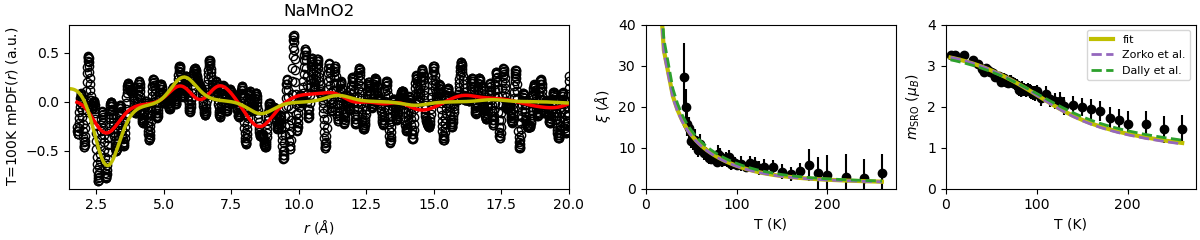

In [70]:
from matplotlib.gridspec import GridSpec

labelsize=10
ticksize=10

colors = ['tab:purple', 'tab:green', 'tab:blue', 'tab:orange', 'tab:red', 'tab:brown']

fig = plt.figure(layout="constrained", figsize=(12, 2.4))
gs = GridSpec(1, 4, figure=fig)
ax_mpdf = fig.add_subplot(gs[0, 0:2])
ax1 = fig.add_subplot(gs[0, 2])
ax2 = fig.add_subplot(gs[0, 3])

ax_mpdf.plot(rdat, mpdf_obs, 'bo', label="mPDF(r) data",
             markerfacecolor='none', markeredgecolor='black')
ax_mpdf.plot(rdat, mpdf_calc, 'r-', lw=2.5, label="mPDF(r) atomistic fit")
ax_mpdf.plot(rcalc, dcalc, 'y-', lw=2.5, label='mPDF(r) from exchange fits')
ax_mpdf.set_title('NaMnO2')
ax_mpdf.set_xlim(1.5, 20)
# ax_mpdf.set_ylim(-0.8, 0.6)
ax_mpdf.set_xlabel(r'$r$ ($\AA$)', fontsize=labelsize)
ax_mpdf.set_ylabel(r'T=100K mPDF$(r)$ (a.u.)',fontsize=labelsize)

ax1.scatter(data_temps, xi_data, c='black', label=r'data')
ax1.errorbar(data_temps, xi_data, yerr=xi_err, fmt='none', c='black')
ax1.plot(temps, xis_fit, '-', c='y', lw=3, label='fit', alpha=1)
for i in range(2):
    ax1.plot(temps, xis_list[i], '--', alpha=1, c=colors[i], lw=2, label=j_ij_names[i])
ax1.set_xlim(0, 275)
ax1.set_ylim(0, 40)
ax1.set_xlabel('T (K)', fontsize=labelsize)
ax1.set_ylabel(r'$\xi$ ($\AA$)', fontsize=labelsize)
ax1.tick_params(axis = 'x', labelsize=ticksize)
ax1.tick_params(axis = 'y', labelsize=ticksize)

ax2.scatter(data_temps, lmop_data, c = 'black')
ax2.errorbar(data_temps, lmop_data, yerr = lmop_err, fmt = 'none', c = 'black')
ax2.plot(temps, lmops_fit, c = 'y', lw=3, label='fit', alpha=1)
for i in range(2):
    ax2.plot(temps, lmop_list[i], '--', lw=2, alpha=1, c=colors[i], label=j_ij_names[i])
ax2.set_xlim(0, 275)
ax2.set_ylim(0, 4)
ax2.set_xlabel('T (K)', fontsize = labelsize)
ax2.set_ylabel(r'$m_{\mathrm{SRO}}$ ($\mu_B$)', fontsize=labelsize)
ax2.legend(fontsize=8)
ax2.tick_params(axis='x', labelsize=ticksize)
ax2.tick_params(axis='y', labelsize=ticksize)

plt.savefig('figures/NaMnO2Fits.png', dpi=1200)
plt.show()

# Cost Surface

In [29]:
def cost(theta, spin_sq=2.4):    
    j1, j2 = theta
    j_ij = [j1, j2]
    
    if j2 < j1 or j1 == 0:
        return np.inf
    
    j_ratio = j2 / j1
    kvecx = 0.5 + (np.arcsin(j_ratio * np.sqrt(1 - 0.25 * j_ratio**2)) - np.arccos(-0.5 * j_ratio)) / (2 * np.pi)
    kvecy = -np.arccos(-0.5 * j_ratio) / (2 * np.pi)
    
    magint = maginteractions.MagInteractions(magstruc=magstruc, temperatures=temps, j_ij=j_ij,
                                                 spin_squared=spin_sq, r_max=r_max, spin_dim=3)
    magint.make_interaction_matrix()
    magint.filter_spin_positions()

    ord_vec = np.array([kvecx, kvecy, 0]) @ magint.recip_lats

    magint.calculate_correlation_parameters(ord_vec=ord_vec, n_ord_vec=n_ord_vec, calc_orf=True,
                                            dim=dim, sum_rule_orf=False, n_bz_vecs=4, isotropic=False)
    xis = np.sort(np.linalg.eigvals(magint.damping_matrices), axis=1)[:,0]**(-1/2)
    lmops = magint.lmops
    
    xis = xis[high_idx:]
    lmops = lmops
    
    res = np.concatenate([xis,lmops]) - np.concatenate([xi_high_data, lmop_data])
    weights = 1/np.concatenate([xi_high_err,lmop_err])
    res *= weights
    res = np.nan_to_num(res,nan=1e4)

    cost = 0.5 * np.sum(res ** 2)
    return cost

In [30]:
j1s = np.arange(-70, -60)
j2s = np.arange(-30, -20)

cost_surface = np.zeros((len(j1s), len(j2s)))

for i in range(len(j2s)):
    for j in range(len(j1s)):
        print(j1s[j], j2s[i])
        cost_surface[j, i] = cost([j1s[j], j2s[i]])

-70 -30
-69 -30
-68 -30
-67 -30
-66 -30
-65 -30
-64 -30
-63 -30
-62 -30
-61 -30
-70 -29
-69 -29
-68 -29
-67 -29
-66 -29
-65 -29
-64 -29
-63 -29
-62 -29
-61 -29
-70 -28
-69 -28
-68 -28
-67 -28
-66 -28
-65 -28
-64 -28
-63 -28
-62 -28
-61 -28
-70 -27
-69 -27
-68 -27
-67 -27
-66 -27
-65 -27
-64 -27
-63 -27
-62 -27
-61 -27
-70 -26
-69 -26
-68 -26
-67 -26
-66 -26
-65 -26
-64 -26
-63 -26
-62 -26
-61 -26
-70 -25
-69 -25
-68 -25
-67 -25
-66 -25
-65 -25
-64 -25
-63 -25
-62 -25
-61 -25
-70 -24
-69 -24
-68 -24
-67 -24
-66 -24
-65 -24
-64 -24
-63 -24
-62 -24
-61 -24
-70 -23
-69 -23
-68 -23
-67 -23
-66 -23
-65 -23
-64 -23
-63 -23
-62 -23
-61 -23
-70 -22
-69 -22
-68 -22
-67 -22
-66 -22
-65 -22
-64 -22
-63 -22
-62 -22
-61 -22
-70 -21
-69 -21
-68 -21
-67 -21
-66 -21
-65 -21
-64 -21
-63 -21
-62 -21
-61 -21


<IPython.core.display.Javascript object>


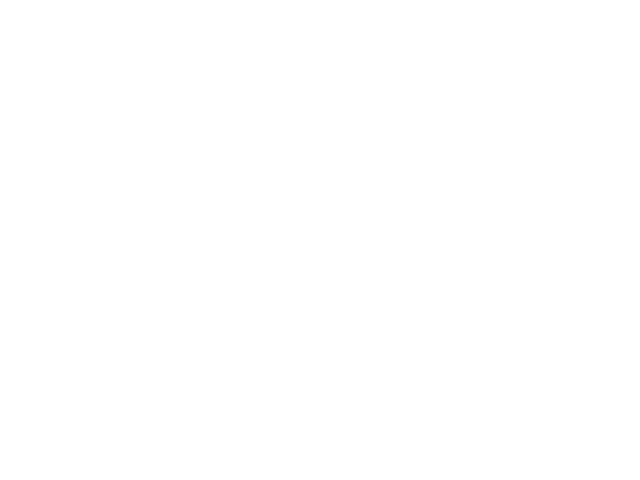

In [31]:
plt.figure()
plt.imshow(
    cost_surface,
    extent=[j2s.min(), j2s.max(), j1s.min(), j1s.max()],
    vmax=36,
    origin='lower',
    aspect='auto',
    cmap='YlOrBr',
)
plt.colorbar(label='Cost')
plt.xlabel('J2')
plt.ylabel('J1')
plt.title('Cost Surface')
plt.show()

In [32]:
np.min(cost_surface)

28.474155285448695